Loading KDD Cup 1999 dataset...
Dataset Shape: (494021, 41)


/tmp/ipykernel_5331/2299087505.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X[column] = pd.to_numeric(X[column], errors="ignore")



After preprocessing:
   0   1   2   3     4     5   6   7   8   9   ...   31   32    33    34  \
0   0   0  14   9  1032     0   0   0   0   0  ...  255  255  1.00  0.00   
1   0   0  14   9  1032     0   0   0   0   0  ...  255  255  1.00  0.00   
2   0   0  14   9  1032     0   0   0   0   0  ...  255  255  1.00  0.00   
3   0   1  22   9   345  5419   0   0   0   0  ...  101  255  1.00  0.00   
4   0   1  45   5     0     0   0   0   0   0  ...  255    2  0.01  0.07   

     35    36   37   38   39   40  
0  1.00  0.00  0.0  0.0  0.0  0.0  
1  1.00  0.00  0.0  0.0  0.0  0.0  
2  1.00  0.00  0.0  0.0  0.0  0.0  
3  0.01  0.02  0.0  0.0  0.0  0.0  
4  0.00  0.00  1.0  1.0  0.0  0.0  

[5 rows x 41 columns]

Data standardization completed.

PCA completed.
Explained Variance:
[0.25951826 0.11930528]

Detecting outliers...
Total Data Points: 494021
Number of Outliers: 9863
Number of Normal Points: 484158


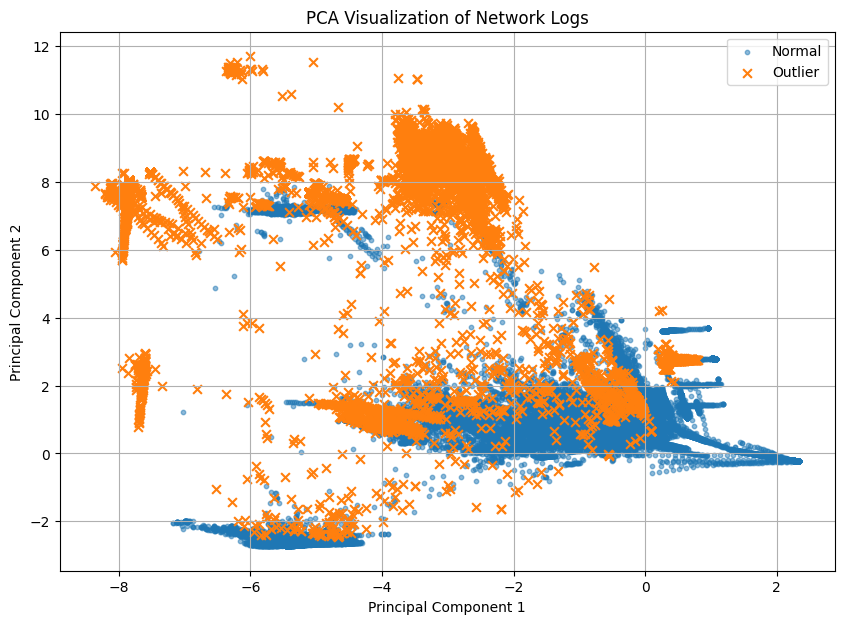


Running t-SNE...
t-SNE completed.


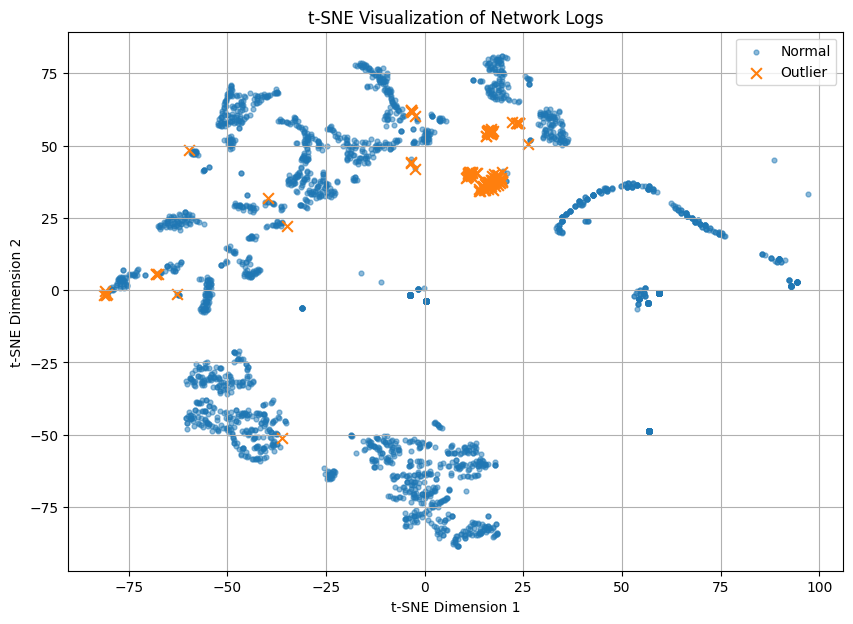


Results saved as:
network_logs_with_outliers.csv

========== OUTLIER RECORDS ==========
         0  1   2  3    4    5  6  7  8  9  ...    33    34    35    36    37  \
14       0  1  22  1    0    0  0  0  0  0  ...  1.00  0.00  0.50  0.16  0.00   
23       0  1  22  1    0    0  0  0  0  0  ...  1.00  0.00  1.00  0.20  0.00   
88       0  1  22  1    0    0  0  0  0  0  ...  1.00  0.00  0.02  0.06  0.00   
97       0  1  22  1    0    0  0  0  0  0  ...  1.00  0.00  0.25  0.09  0.00   
248      0  1  40  1    0    0  0  0  0  0  ...  0.00  1.00  0.00  0.00  0.00   
305   6911  2  40  9  145  105  0  0  0  0  ...  0.01  0.62  0.92  0.00  0.00   
660      0  1  22  1    0    0  0  0  0  0  ...  1.00  0.00  0.33  0.14  0.00   
894      0  1  40  4    0    0  0  0  0  0  ...  0.00  0.62  1.00  0.00  0.00   
896      0  1  45  1    0    0  0  0  0  0  ...  0.00  1.00  1.00  0.00  0.00   
1138     0  0  13  9    8    0  0  0  0  0  ...  1.00  0.00  1.00  0.52  0.00   
1186     0  1  22  1

In [ ]:
# ==========================================
# HIGH-DIMENSIONAL NETWORK LOG VISUALIZATION
# PCA + t-SNE + OUTLIER DETECTION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# ------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------

print("Loading KDD Cup 1999 dataset...")

data = fetch_kddcup99(
    subset=None,
    percent10=True,
    shuffle=True,
    random_state=42
)

X = pd.DataFrame(data.data)

print("Dataset Shape:", X.shape)

# ------------------------------------------
# 2. HANDLE COLUMN TYPES
# ------------------------------------------

# Convert byte/string values to normal strings
for column in X.columns:
    X[column] = X[column].apply(
        lambda x: x.decode("utf-8", errors="ignore")
        if isinstance(x, bytes) else x
    )

# Convert numeric-looking columns to numbers
for column in X.columns:
    X[column] = pd.to_numeric(X[column], errors="ignore")

# ------------------------------------------
# 3. ENCODE CATEGORICAL FEATURES
# ------------------------------------------

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(
        X[column].astype(str)
    )

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Handle missing values
X = X.fillna(0)

print("\nAfter preprocessing:")
print(X.head())

# ------------------------------------------
# 4. STANDARDIZE DATA
# ------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData standardization completed.")

# ------------------------------------------
# 5. PCA
# ------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA completed.")

print("Explained Variance:")
print(pca.explained_variance_ratio_)

# ------------------------------------------
# 6. OUTLIER DETECTION
# ------------------------------------------

print("\nDetecting outliers...")

isolation_forest = IsolationForest(
    contamination=0.02,
    random_state=42
)

outlier_prediction = isolation_forest.fit_predict(X_scaled)

# -1 = Outlier
#  1 = Normal

outliers = outlier_prediction == -1

print("Total Data Points:", len(X))
print("Number of Outliers:", np.sum(outliers))
print("Number of Normal Points:", np.sum(~outliers))

# ------------------------------------------
# 7. PCA VISUALIZATION WITH OUTLIERS
# ------------------------------------------

plt.figure(figsize=(10, 7))

# Normal points
plt.scatter(
    X_pca[~outliers, 0],
    X_pca[~outliers, 1],
    alpha=0.5,
    s=10,
    label="Normal"
)

# Outliers
plt.scatter(
    X_pca[outliers, 0],
    X_pca[outliers, 1],
    s=40,
    marker="x",
    label="Outlier"
)

plt.title("PCA Visualization of Network Logs")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------
# 8. t-SNE
# ------------------------------------------

print("\nRunning t-SNE...")

# Use a smaller sample for faster execution
sample_size = min(5000, len(X_scaled))

np.random.seed(42)

sample_indices = np.random.choice(
    len(X_scaled),
    sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]
outlier_sample = outliers[sample_indices]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(X_sample)

print("t-SNE completed.")

# ------------------------------------------
# 9. t-SNE VISUALIZATION WITH OUTLIERS
# ------------------------------------------

plt.figure(figsize=(10, 7))

# Normal points
plt.scatter(
    X_tsne[~outlier_sample, 0],
    X_tsne[~outlier_sample, 1],
    alpha=0.5,
    s=12,
    label="Normal"
)

# Outliers
plt.scatter(
    X_tsne[outlier_sample, 0],
    X_tsne[outlier_sample, 1],
    s=60,
    marker="x",
    label="Outlier"
)

plt.title("t-SNE Visualization of Network Logs")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------
# 10. SAVE OUTLIER RESULTS
# ------------------------------------------

result = X.copy()

result["Outlier"] = outliers

result["Outlier_Status"] = result["Outlier"].map({
    True: "Outlier",
    False: "Normal"
})

result.to_csv(
    "network_logs_with_outliers.csv",
    index=False
)

print("\nResults saved as:")
print("network_logs_with_outliers.csv")

# ------------------------------------------
# 11. DISPLAY OUTLIERS
# ------------------------------------------

print("\n========== OUTLIER RECORDS ==========")

print(
    result[result["Outlier"] == True].head(20)
)

print("\nOutlier detection completed!")